In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
np.random.seed(42)

n=200

data=pd.DataFrame({
    "experience":np.random.randint(0,15,n),
    "education_years":np.random.randint(0,20,n),
    "age":np.random.randint(22,60,n),
})

data["salary"]=(
    30000+
    data["experience"]*4000+
    data["education_years"]*2000+
    data["age"]*500+
    np.random.randn(n)*10000
)

data.head()

,experience,education_years,age,salary
0,6,4,22,65815.557787
1,3,6,29,66365.528483
2,12,12,37,123609.075656
3,14,14,35,146253.562169
4,10,10,33,115076.596232


In [3]:
print(data.shape)
print(data.info())
print(data.describe())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       200 non-null    int64  
 1   education_years  200 non-null    int64  
 2   age              200 non-null    int64  
 3   salary           200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB
None
       experience  education_years         age         salary
count  200.000000       200.000000  200.000000     200.000000
mean     7.450000         8.970000   41.265000   97864.749061
std      4.320978         6.331631   10.961549   25212.079644
min      0.000000         0.000000   22.000000   32451.178993
25%      4.000000         3.000000   33.000000   79603.995678
50%      7.500000         8.000000   42.500000   96789.563648
75%     11.000000        15.000000   51.000000  114465.361169
max     14.000000        19.000000   59.000000  164647.25132

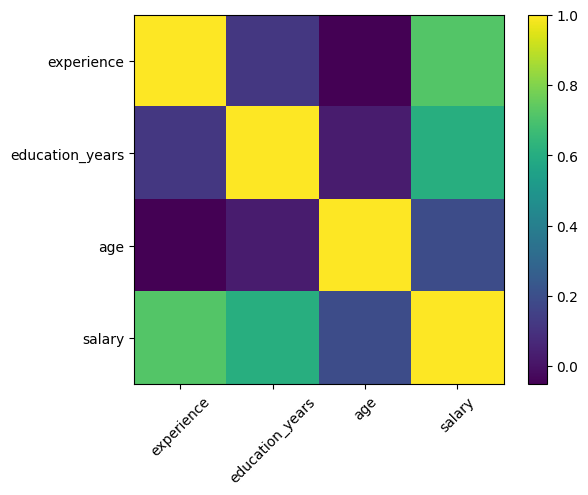

In [4]:
corr=data.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.show()

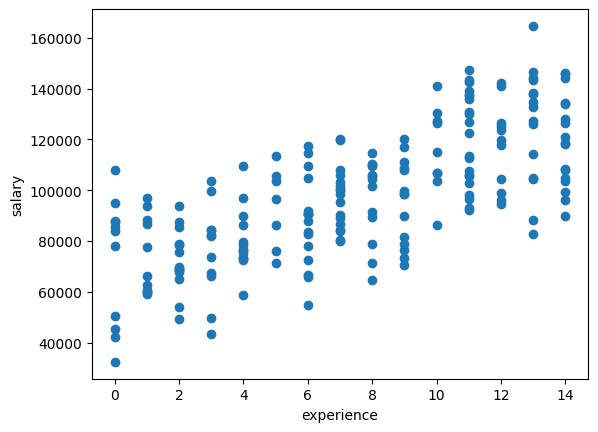

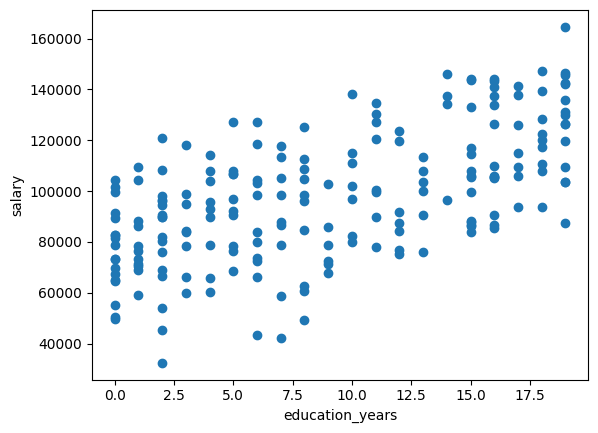

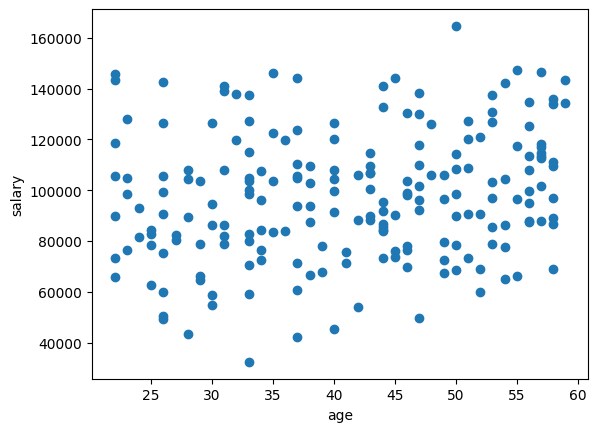

In [5]:
features=["experience","education_years","age"]

for col in features:
  plt.figure()
  plt.scatter(data[col],data["salary"])
  plt.xlabel(col)
  plt.ylabel("salary")
  plt.show()

In [13]:
x=data[["experience","education_years","age"]]
y=data["salary"]

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [17]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [22]:
print(model.coef_)
print(model.intercept_)

[3852.16355814 2017.1385051   503.11275777]
30217.421724160522


In [25]:
y_pred=model.predict(x_test)

In [26]:
mse=mean_squared_error(y_test,y_pred)
rsme=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print(mse,rsme,r2)

85286680.09914708 9235.078781426128 0.8759280167151726


In [27]:
new_data=pd.DataFrame({
    "experience":[5],
    "education_years":[16],
    "age":[30]
})

print(model.predict(new_data))

[96845.83832963]
